In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (PROJECT_ROOT / "data" / "processed" / "tatarstan_economic_data_clean.csv")
df = pd.read_csv(DATA_PATH)

model_df = (df[["year","unemployment_diff","investment_diff","grp_log_growth"]].dropna().reset_index(drop=True))
model_df.tail()

,year,unemployment_diff,investment_diff,grp_log_growth
20,2021,-1.000,26.550,0.142387
21,2022,-0.375,-12.850,0.094490
22,2023,-0.190,-1.750,0.073304
23,2024,-0.235,-1.575,0.065460
24,2025,-0.125,2.400,0.059514


In [2]:
y = model_df["unemployment_diff"].values
X = model_df[["investment_diff", "grp_log_growth"]].copy()

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std
with pm.Model() as model:
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )
    beta_investment = pm.Normal(
        "beta_investment",
        mu=0,
        sigma=1
    )
    beta_grp = pm.Normal(
        "beta_grp",
        mu=0,
        sigma=1
    )
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )
    mu = (
        intercept
        + beta_investment * X_scaled["investment_diff"].values
        + beta_grp * X_scaled["grp_log_growth"].values
    )
    unemployment_obs = pm.Normal(
        "unemployment_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_investment, beta_grp, sigma]


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [3]:
scenarios = pd.DataFrame({
    "scenario": [
        "Base",
        "Optimistic",
        "Stress"
    ],
    "investment_diff": [
        0.0,
        10.0,
        -10.0
    ],
    "grp_log_growth": [
        0.08,
        0.12,
        0.00
    ]
})
scenarios

,scenario,investment_diff,grp_log_growth
0,Base,0.0,0.08
1,Optimistic,10.0,0.12
2,Stress,-10.0,0.00


In [4]:
scenarios["investment_scaled"] = (scenarios["investment_diff"]- X_mean["investment_diff"]) / X_std["investment_diff"]
scenarios["grp_scaled"] = (scenarios["grp_log_growth"]- X_mean["grp_log_growth"]) / X_std["grp_log_growth"]
scenarios

,scenario,investment_diff,grp_log_growth,investment_scaled,grp_scaled
0,Base,0.0,0.08,0.067580,-0.340100
1,Optimistic,10.0,0.12,0.935103,0.235155
2,Stress,-10.0,0.00,-0.799943,-1.490609


In [5]:
intercept_mean = (trace.posterior["intercept"].mean().item())

beta_investment_mean = (trace.posterior["beta_investment"].mean().item())
beta_grp_mean = (trace.posterior["beta_grp"].mean().item())

scenarios["predicted_unemployment_change"] = (intercept_mean+ beta_investment_mean* scenarios["investment_scaled"]+ beta_grp_mean* scenarios["grp_scaled"])

scenarios[
    [
        "scenario",
        "investment_diff",
        "grp_log_growth",
        "predicted_unemployment_change"
    ]
]

,scenario,investment_diff,grp_log_growth,predicted_unemployment_change
0,Base,0.0,0.08,-0.286145
1,Optimistic,10.0,0.12,-0.709930
2,Stress,-10.0,0.00,0.374130


In [6]:
last_unemployment = df.loc[
    df["year"] == 2025,
    "unemployment_rate"
].iloc[0]

forecast_years = [2026, 2027, 2028]
forecast_rows = []
for _, row in scenarios.iterrows():
    unemployment_rate = last_unemployment
    for year in forecast_years:
        unemployment_rate += (
            row["predicted_unemployment_change"]
        )
        forecast_rows.append({
            "year": year,
            "scenario": row["scenario"],
            "unemployment_rate": unemployment_rate
        })

scenario_forecast = pd.DataFrame(forecast_rows)
scenario_forecast

,year,scenario,unemployment_rate
0,2026,Base,1.438855
1,2027,Base,1.152710
2,2028,Base,0.866565
3,2026,Optimistic,1.015070
4,2027,Optimistic,0.305141
5,2028,Optimistic,-0.404789
6,2026,Stress,2.099130
7,2027,Stress,2.473261
8,2028,Stress,2.847391


In [7]:
forecast_table = scenario_forecast.pivot(
    index="year",
    columns="scenario",
    values="unemployment_rate"
).round(2)
forecast_table

scenario,Base,Optimistic,Stress
year,,,
2026,1.44,1.02,2.10
2027,1.15,0.31,2.47
2028,0.87,-0.40,2.85


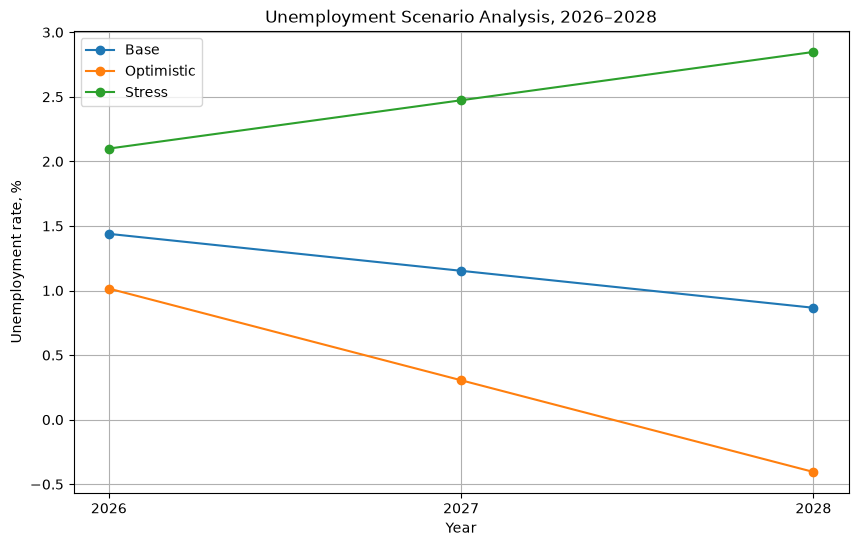

In [8]:
plt.figure(figsize=(10, 6))

for scenario in scenario_forecast["scenario"].unique():
    scenario_data = scenario_forecast[
        scenario_forecast["scenario"] == scenario
    ]
    plt.plot(
        scenario_data["year"],
        scenario_data["unemployment_rate"],
        marker="o",
        label=scenario
    )
plt.title("Unemployment Scenario Analysis, 2026–2028")
plt.xlabel("Year")
plt.ylabel("Unemployment rate, %")
plt.xticks(forecast_years)
plt.grid(True)
plt.legend()

plt.show()

Three illustrative economic scenarios were evaluated for 2026–2028:
- Base:stable investment dynamics and moderate GRP growth.
- Optimistic: stronger investment dynamics and higher GRP growth.
- Stress: declining investment dynamics and zero GRP growth.
The model associates stronger investment and GRP growth with declining unemployment, while the stress scenario produces an increase in unemployment.
The scenarios are illustrative what-if simulations rather than forecasts of actual future macroeconomic conditions. They assume that scenario conditions remain constant over the forecast horizon.

Были проанализированы три показательных экономических сценария на 2026–2028 годы:

- Базовый: стабильная динамика инвестиций и умеренный рост ВВП.
- Оптимистичный: более сильная динамика инвестиций и более высокий рост ВВП.
- Стрессовый: снижение динамики инвестиций и нулевой рост ВВП.

Модель предполагает, что более высокие темпы роста инвестиций и валового продукта приведут к снижению безработицы, в то время как стрессовый сценарий предполагает рост безработицы.
Сценарии представляют собой иллюстративные модели «что, если», а не прогнозы реальных макроэкономических условий в будущем. Предполагается, что условия в рамках сценариев останутся неизменными в течение прогнозируемого периода.